# Debug: dynamic min_samples_leaf policy vs default surrogate

Compare two 400-trial Hartmann 6D SMAC runs:

- dynamic RF policy: `min_samples_leaf = 1 -> 2 -> 3 -> 4`, switching every 100 trials
- default SMAC HPO surrogate model

Both runs use seed 0 and 25 Sobol initial configurations.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/py3.12-smac/lib64/python3.9/site-packages/traitlets/traitlets.py", line 668,

In [2]:
ROOT = Path("/home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug")
DYNAMIC_DIR = ROOT / "debug_dynamic_leaf_policy_1_2_3_4" / "dynamic_leaf_policy_1_2_3_4" / "0"
DEFAULT_DIR = ROOT / "debug_default_surrogate" / "default_surrogate" / "0"
FIGURE_DIRECTORY = ROOT / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("dynamic dir:", DYNAMIC_DIR, DYNAMIC_DIR.exists())
print("default dir:", DEFAULT_DIR, DEFAULT_DIR.exists())

dynamic dir: /home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug/debug_dynamic_leaf_policy_1_2_3_4/dynamic_leaf_policy_1_2_3_4/0 True
default dir: /home/io632776/experiments/adaptive-smac/experiments/hartmann/Debug/debug_default_surrogate/default_surrogate/0 True


## Load run histories

In [3]:
def load_runhistory(run_dir: Path) -> dict:
    with open(run_dir / "runhistory.json") as fh:
        return json.load(fh)


def ordered_trials(runhistory: dict) -> list[dict]:
    configs = {str(config_id): config for config_id, config in runhistory["configs"].items()}
    origins = {str(config_id): origin for config_id, origin in runhistory.get("config_origins", {}).items()}
    rows = sorted(runhistory["data"], key=lambda row: (row["starttime"], row["endtime"]))

    ordered = []
    for trial_number, row in enumerate(rows, start=1):
        config_id = str(row["config_id"])
        ordered.append(
            {
                "trial": trial_number,
                "config_id": config_id,
                "config": configs[config_id],
                "cost": float(row["cost"]),
                "origin": origins.get(config_id),
            }
        )
    return ordered


def best_so_far(costs):
    return np.minimum.accumulate(np.asarray(costs, dtype=float))


dynamic_rh = load_runhistory(DYNAMIC_DIR)
default_rh = load_runhistory(DEFAULT_DIR)

dynamic_trials = ordered_trials(dynamic_rh)
default_trials = ordered_trials(default_rh)

print("dynamic trials:", len(dynamic_trials))
print("default trials:", len(default_trials))

dynamic trials: 400
default trials: 400


## Scenario metadata comparison

In [4]:
def load_scenario(run_dir: Path) -> dict:
    with open(run_dir / "scenario.json") as fh:
        return json.load(fh)


dynamic_scenario = load_scenario(DYNAMIC_DIR)
default_scenario = load_scenario(DEFAULT_DIR)

metadata_rows = []
for label, scenario in [("dynamic", dynamic_scenario), ("default", default_scenario)]:
    meta = scenario.get("_meta", {})
    model = meta.get("model", {})
    initial_design = meta.get("initial_design", {})
    metadata_rows.append(
        {
            "run": label,
            "name": scenario.get("name"),
            "n_trials": scenario.get("n_trials"),
            "seed": scenario.get("seed"),
            "initial_design_n_configs": initial_design.get("n_configs"),
            "model_min_samples_leaf": model.get("min_samples_leaf"),
            "model_max_depth": model.get("max_depth"),
            "model_random_state": model.get("random_state"),
        }
    )

pd.DataFrame(metadata_rows)

,run,name,n_trials,seed,initial_design_n_configs,model_min_samples_leaf,model_max_depth,model_random_state
0,dynamic,dynamic_leaf_policy_1_2_3_4,400,0,25,1,1048576,0
1,default,default_surrogate,400,0,25,1,1048576,0


## Best-so-far trajectory overlay

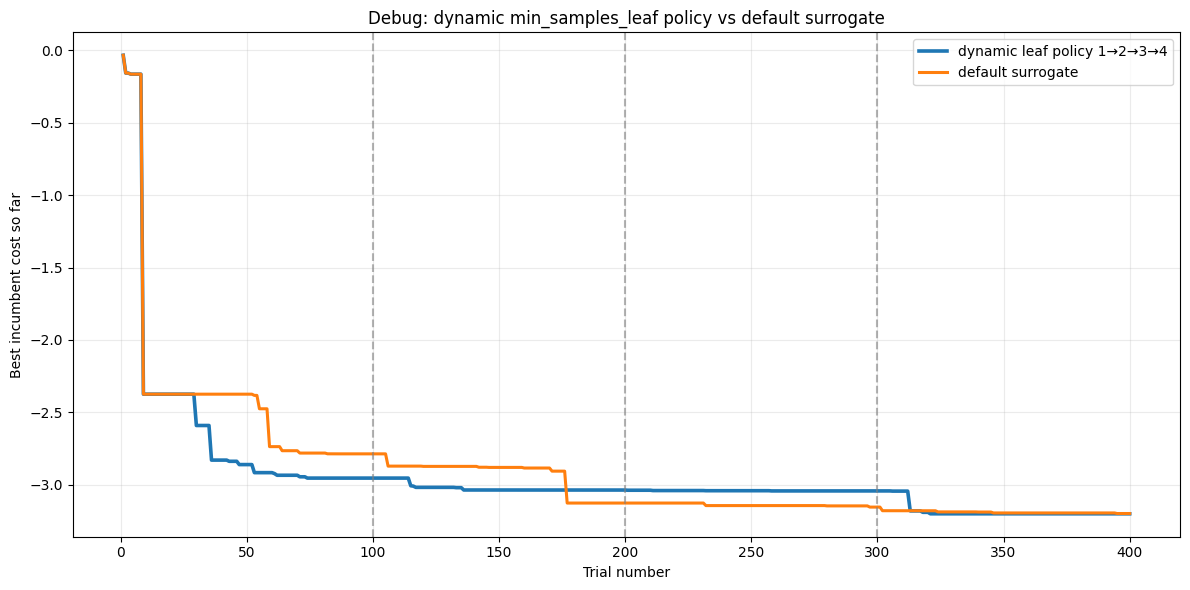

In [5]:
dynamic_costs = np.asarray([trial["cost"] for trial in dynamic_trials])
default_costs = np.asarray([trial["cost"] for trial in default_trials])
dynamic_best = best_so_far(dynamic_costs)
default_best = best_so_far(default_costs)

xs = np.arange(1, min(len(dynamic_best), len(default_best)) + 1)

plt.figure(figsize=(12, 6))
plt.plot(xs, dynamic_best[: len(xs)], label="dynamic leaf policy 1→2→3→4", linewidth=2.6)
plt.plot(xs, default_best[: len(xs)], label="default surrogate", linewidth=2.2)
for boundary in [100, 200, 300]:
    plt.axvline(boundary, color="gray", linestyle="--", alpha=0.6)
plt.title("Debug: dynamic min_samples_leaf policy vs default surrogate")
plt.xlabel("Trial number")
plt.ylabel("Best incumbent cost so far")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "dynamic_leaf_policy_vs_default_surrogate.png", dpi=200)
plt.show()

## Direct trial-by-trial comparison

In [6]:
comparison_rows = []
first_difference = None
for dynamic_trial, default_trial in zip(dynamic_trials, default_trials):
    same_config = dynamic_trial["config"] == default_trial["config"]
    same_cost = np.isclose(dynamic_trial["cost"], default_trial["cost"], rtol=0, atol=1e-15)
    if first_difference is None and (not same_config or not same_cost):
        first_difference = dynamic_trial["trial"]

    comparison_rows.append(
        {
            "trial": dynamic_trial["trial"],
            "same_config": same_config,
            "same_cost": bool(same_cost),
            "dynamic_cost": dynamic_trial["cost"],
            "default_cost": default_trial["cost"],
            "dynamic_origin": dynamic_trial["origin"],
            "default_origin": default_trial["origin"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
print("first_difference:", first_difference)
comparison_df.head(35)

first_difference: 26


,trial,same_config,same_cost,dynamic_cost,default_cost,dynamic_origin,default_origin
0,1,True,True,-0.034167,-0.034167,Initial Design: Sobol,Initial Design: Sobol
1,2,True,True,-0.157265,-0.157265,Initial Design: Sobol,Initial Design: Sobol
2,3,True,True,-0.117585,-0.117585,Initial Design: Sobol,Initial Design: Sobol
3,4,True,True,-0.164613,-0.164613,Initial Design: Sobol,Initial Design: Sobol
4,5,True,True,-0.108812,-0.108812,Initial Design: Sobol,Initial Design: Sobol
5,6,True,True,-0.143232,-0.143232,Initial Design: Sobol,Initial Design: Sobol
6,7,True,True,-0.150772,-0.150772,Initial Design: Sobol,Initial Design: Sobol
7,8,True,True,-0.039170,-0.039170,Initial Design: Sobol,Initial Design: Sobol
8,9,True,True,-2.374172,-2.374172,Initial Design: Sobol,Initial Design: Sobol
9,10,True,True,-0.036580,-0.036580,Initial Design: Sobol,Initial Design: Sobol


In [7]:
if first_difference is not None:
    window = comparison_df[
        comparison_df["trial"].between(max(1, first_difference - 5), first_difference + 5)
    ]
    display(window)

    dynamic_config = dynamic_trials[first_difference - 1]["config"]
    default_config = default_trials[first_difference - 1]["config"]
    config_diff_df = pd.DataFrame(
        {
            "dynamic": dynamic_config,
            "default": default_config,
        }
    )
    config_diff_df["abs_diff"] = (config_diff_df["dynamic"] - config_diff_df["default"]).abs()
    display(config_diff_df)

,trial,same_config,same_cost,dynamic_cost,default_cost,dynamic_origin,default_origin
20,21,True,True,-0.346825,-0.346825,Initial Design: Sobol,Initial Design: Sobol
21,22,True,True,-0.007197,-0.007197,Initial Design: Sobol,Initial Design: Sobol
22,23,True,True,-0.091317,-0.091317,Initial Design: Sobol,Initial Design: Sobol
23,24,True,True,-0.001190,-0.001190,Initial Design: Sobol,Initial Design: Sobol
24,25,True,True,-0.414354,-0.414354,Initial Design: Sobol,Initial Design: Sobol
25,26,False,False,-1.655657,-0.516194,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
26,27,False,False,-1.188481,-2.367356,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
27,28,False,False,-0.093555,-0.194095,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
28,29,False,False,-1.582223,-2.263468,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search
29,30,False,False,-2.590397,-0.595842,Acquisition Function Maximizer: Local Search,Acquisition Function Maximizer: Local Search


,dynamic,default,abs_diff
x1,0.453635,0.326361,0.127273
x2,0.980070,0.987182,0.007112
x3,0.933277,0.938854,0.005578
x4,0.807155,0.976108,0.168952
x5,0.086916,0.065105,0.021812
x6,0.034194,0.002177,0.032016


## Raw costs overlay

This is sometimes easier for seeing whether the two runs are identical before the first best-so-far improvement difference.

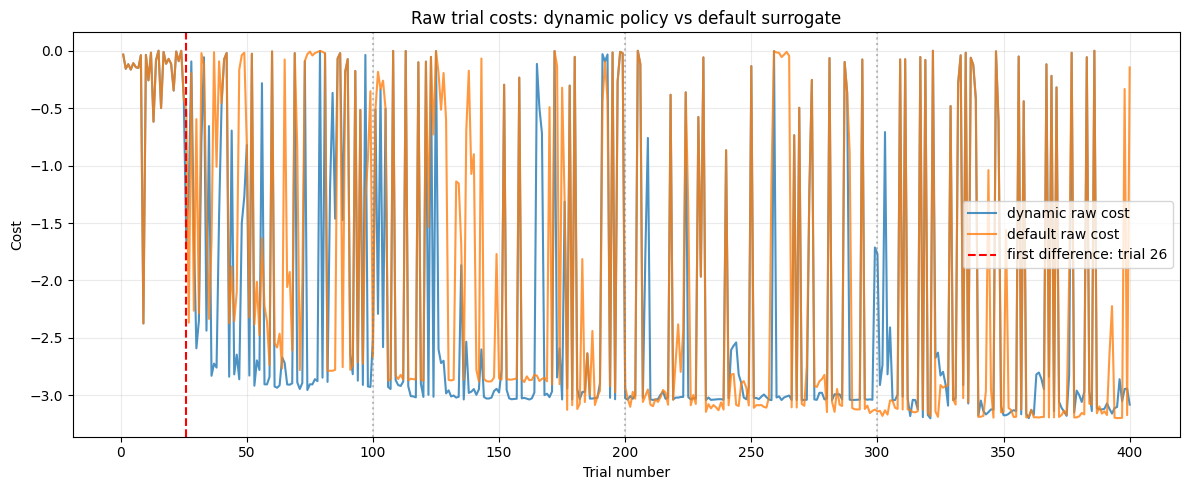

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(xs, dynamic_costs[: len(xs)], label="dynamic raw cost", alpha=0.8)
plt.plot(xs, default_costs[: len(xs)], label="default raw cost", alpha=0.8)
if first_difference is not None:
    plt.axvline(first_difference, color="red", linestyle="--", label=f"first difference: trial {first_difference}")
for boundary in [100, 200, 300]:
    plt.axvline(boundary, color="gray", linestyle=":", alpha=0.5)
plt.title("Raw trial costs: dynamic policy vs default surrogate")
plt.xlabel("Trial number")
plt.ylabel("Cost")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIRECTORY / "dynamic_leaf_policy_vs_default_raw_costs.png", dpi=200)
plt.show()